# Global Gate 1 — Fuzzy Calibration

This notebook applies the Step 1 calibration method from `D/D_S3_fuzzy_calibration.ipynb` to the curated Global candidate set.

- Every repeat remains an independent calibration case.
- Human labels are `0`, `0.5`, and `1`.
- MIC is calibrated with a piecewise-linear fuzzy membership function.
- The pooled Standard + Strong fit is the primary result; variant-specific fits are retained as a stability check.
- The 100 Null cases have no SNR and are evaluated as independent negative controls.


In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.matplotlib').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from minepy import MINE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)

cwd = Path.cwd().resolve()
project_root = next(
    (root for root in [cwd, *cwd.parents]
     if (root / 'D' / 'Global' / 'output' / 'S1_gate1_preview' / 'gate1_candidate_manifest.csv').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Could not locate the project root and Global Gate 1 candidate set.')

input_dir = project_root / 'D' / 'Global' / 'output' / 'S1_gate1_preview'
source_metrics_path = project_root / 'D' / 'output' / 'S2' / 'metrics_full.parquet'
output_dir = project_root / 'D' / 'Global' / 'output' / 'S2_gate1_fuzzy_calibration'
output_dir.mkdir(parents=True, exist_ok=True)

manifest_path = input_dir / 'gate1_candidate_manifest.csv'
points_path = input_dir / 'gate1_candidate_points.npz'

manifest = pd.read_csv(manifest_path, low_memory=False)
with np.load(points_path) as point_data:
    x_candidates = point_data['x'].copy()
    y_candidates = point_data['y'].copy()

assert len(manifest) == len(x_candidates) == len(y_candidates)
assert manifest['candidate_index'].tolist() == list(range(len(manifest)))
assert manifest['plot_id'].is_unique

print(f'Candidates: {len(manifest):,}')
print(f'Points per candidate: {x_candidates.shape[1]}')
print(f'Input:  {input_dir}')
print(f'Output: {output_dir}')


Candidates: 1,640
Points per candidate: 500
Input:  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview
Output: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration


## 1. Resolve the human labels

The curated manifest is the label source. SNR 4 is present for every signal family. The previously reviewed F23/F24 SNR 4 decisions are explicitly fixed at label `1` for reproducibility.

This cell is the single place to change those pending decisions before recalibration.


In [2]:
# Explicitly preserve the focused F23/F24 SNR 4 review decisions.
SNR4_LABEL_OVERRIDES = {
    ('F23', 4.0): 1.0,
    ('F24', 4.0): 1.0,
}

calibrated = manifest.copy()
calibrated['label_before_calibration'] = pd.to_numeric(calibrated['label'], errors='coerce')
calibrated['label'] = calibrated['label_before_calibration']

for (family_id, nominal_snr), resolved_label in SNR4_LABEL_OVERRIDES.items():
    mask = (
        calibrated['family_id'].eq(family_id)
        & np.isclose(calibrated['nominal_snr'], nominal_snr, rtol=0.0, atol=1e-12)
    )
    if mask.sum() != 10:
        raise ValueError(
            f'Expected 10 {family_id} SNR {nominal_snr:g} cases; found {mask.sum()}'
        )
    calibrated.loc[mask, 'label'] = float(resolved_label)
    calibrated.loc[mask, 'review_status'] = 'labeled'
    calibrated.loc[mask, 'label_source'] = (
        'Global focused SNR 4 review: Standard + Strong, 5 repeats each'
    )

allowed_labels = {0.0, 0.5, 1.0}
assert calibrated['label'].notna().all(), 'All pending labels must be resolved before calibration.'
assert set(calibrated['label'].unique()).issubset(allowed_labels)

# Explicit checks for the latest manual decisions.
def assert_label(family_id, nominal_snr, expected_label, expected_count):
    rows = calibrated[
        calibrated['family_id'].eq(family_id)
        & np.isclose(calibrated['nominal_snr'], nominal_snr, rtol=0.0, atol=1e-12)
    ]
    assert len(rows) == expected_count
    assert np.allclose(rows['label'], expected_label)

assert_label('F13', 5.0, 1.0, 10)
assert_label('F25', 0.5, 0.5, 10)
assert_label('F26', 0.5, 0.5, 10)
assert_label('F23', 4.0, 1.0, 10)
assert_label('F24', 4.0, 1.0, 10)

# Labels should not become clearer as nominal SNR decreases.
monotonic_rows = []
signal_rows = calibrated[calibrated['family_id'].ne('Null')].copy()
for (family_id, variant_level), group in signal_rows.groupby(['family_id', 'variant_level']):
    levels = group.groupby('nominal_snr')['label'].mean().sort_index(ascending=False)
    violations = int(np.sum(np.diff(levels.to_numpy()) > 1e-12))
    monotonic_rows.append({
        'family_id': family_id,
        'variant_level': variant_level,
        'n_snr_levels': len(levels),
        'monotonicity_violations': violations,
    })
label_order_audit = pd.DataFrame(monotonic_rows)
assert label_order_audit['monotonicity_violations'].sum() == 0

print('Final label counts:')
display(calibrated['label'].value_counts().sort_index().rename('cases').to_frame())
print('Explicit F23/F24 SNR 4 decisions:')
display(
    calibrated[
        calibrated['family_id'].isin(['F23', 'F24'])
        & np.isclose(calibrated['nominal_snr'], 4.0, rtol=0.0, atol=1e-12)
    ]
    .groupby(['family_id', 'variant_level', 'nominal_snr', 'label'])
    .size().rename('cases').to_frame()
)
print('Label-order audit: no violations found.')


Final label counts:


,cases
label,
0.0,790
0.5,250
1.0,600


Explicit F23/F24 SNR 4 decisions:


cases
family_id variant_level nominal_snr label       
F23       standard      4.0         1.0        5
          strong        4.0         1.0        5
F24       standard      4.0         1.0        5
          strong        4.0         1.0        5

Label-order audit: no violations found.


## 2. Attach MIC to every calibration case

Signal MIC values are reused from the dense S2 metrics table through `case_id`. MIC is calculated directly for the 100 newly generated independent Null controls, so every metric corresponds to the actual points in this candidate set.


In [3]:
source_metrics = pd.read_parquet(source_metrics_path, columns=['case_id', 'MIC'])
source_metrics = source_metrics.drop_duplicates('case_id')
calibrated = calibrated.merge(source_metrics, on='case_id', how='left', validate='many_to_one')
calibrated['metric_source'] = 'D/output/S2/metrics_full.parquet'

signal_mask = calibrated['family_id'].ne('Null')
if calibrated.loc[signal_mask, 'MIC'].isna().any():
    missing = calibrated.loc[signal_mask & calibrated['MIC'].isna(), 'case_id'].tolist()[:10]
    raise ValueError(f'Missing source MIC values for signal case IDs: {missing}')

def calculate_mic(x_values, y_values):
    valid = np.isfinite(x_values) & np.isfinite(y_values)
    mine = MINE(alpha=0.6, c=15)
    mine.compute_score(
        np.asarray(x_values[valid], dtype=float),
        np.asarray(y_values[valid], dtype=float),
    )
    return float(mine.mic())

null_indices = calibrated.loc[~signal_mask, 'candidate_index'].astype(int).to_numpy()
null_mic = [
    calculate_mic(x_candidates[index], y_candidates[index])
    for index in null_indices
]
calibrated.loc[~signal_mask, 'MIC'] = null_mic
calibrated.loc[~signal_mask, 'metric_source'] = 'computed from Global independent Null points'

# minepy can return values such as 1.0000000000000002 from floating-point arithmetic.
# Preserve the raw result for audit, then enforce the theoretical MIC range.
calibrated['MIC_raw'] = calibrated['MIC']
mic_clipped_count = int((~calibrated['MIC_raw'].between(0.0, 1.0)).sum())
calibrated['MIC'] = calibrated['MIC_raw'].clip(0.0, 1.0)

assert calibrated['MIC'].notna().all()
assert calibrated['MIC'].between(0.0, 1.0).all()

print(f'MIC attached to all calibration cases; clipped {mic_clipped_count} floating-point boundary values.')
display(
    calibrated.groupby(['family_id', 'variant_level'], dropna=False)
    .agg(cases=('candidate_index', 'size'), MIC_mean=('MIC', 'mean'), MIC_sd=('MIC', 'std'))
    .round(4)
)


MIC attached to all calibration cases; clipped 11 floating-point boundary values.


cases  MIC_mean  MIC_sd
family_id variant_level                         
F01       standard          55    0.5211  0.2437
          strong            55    0.5221  0.2403
F03       standard          55    0.4552  0.1976
          strong            55    0.4345  0.1867
F05       standard          55    0.4773  0.2083
          strong            55    0.4564  0.2029
F07       standard          55    0.4200  0.1778
          strong            55    0.3242  0.1158
F13       standard          55    0.5797  0.2701
          strong            55    0.6008  0.2878
F15       standard          55    0.6020  0.2939
          strong            55    0.6227  0.2964
F18       standard          55    0.4862  0.2279
          strong            55    0.4902  0.2274
F19       standard          55    0.2911  0.0915
          strong            55    0.2562  0.0618
F21       standard          55    0.3766  0.1319
          strong            55    0.3732  0.1297
F22       standard          55    0.5254  0.2601
          strong            55    0.5090  0.2604
F23       standard          55    0.2957  0.0866
          strong            55    0.2650  0.0842
F24       standard          55    0.2689  0.0798
          strong            55    0.2639  0.0777
F25       standard          55    0.2845  0.0848
          strong            55    0.2577  0.0709
F26       standard          55    0.2553  0.0604
          strong            55    0.2168  0.0344
Null      none             100    0.1625  0.0131

## 3. Fit the fuzzy MIC interval

For MIC value $z$:

$$\mu(z)=\mathrm{clip}\left(\frac{z-L}{U-L},0,1\right)$$

The grid search selects the `[L,U]` pair with minimum MSE against the human labels. Optional manual overrides apply only to the pooled curve, which is the curve exported for the Global Gate 1 model.


In [4]:
MIC_L_override = None
MIC_U_override = None
ALPHA = 0.5
HARD_MIC_THRESHOLD = 0.8

def fuzzy_mu(values, L, U):
    values = np.asarray(values, dtype=float)
    if U <= L:
        raise ValueError('U must be greater than L.')
    return np.clip((values - L) / (U - L), 0.0, 1.0)

def fit_fuzzy_interval(values, labels, step=0.01):
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels, dtype=float)
    keep = np.isfinite(values) & np.isfinite(labels)
    values, labels = values[keep], labels[keep]
    best = {'mse': np.inf, 'L': np.nan, 'U': np.nan, 'n': len(values)}
    for L_candidate in np.arange(0.0, 0.98, step):
        for U_candidate in np.arange(L_candidate + step, 1.0 + step / 2, step):
            predictions = fuzzy_mu(values, L_candidate, U_candidate)
            mse = float(np.mean((predictions - labels) ** 2))
            if mse < best['mse']:
                best = {
                    'mse': mse,
                    'L': float(L_candidate),
                    'U': float(U_candidate),
                    'n': len(values),
                }
    return best

pooled_fit_auto = fit_fuzzy_interval(calibrated['MIC'], calibrated['label'])
MIC_L = pooled_fit_auto['L'] if MIC_L_override is None else float(MIC_L_override)
MIC_U = pooled_fit_auto['U'] if MIC_U_override is None else float(MIC_U_override)
pooled_fit = dict(pooled_fit_auto)
pooled_fit.update({
    'L_auto': pooled_fit_auto['L'],
    'U_auto': pooled_fit_auto['U'],
    'L': MIC_L,
    'U': MIC_U,
    'manual_override': MIC_L_override is not None or MIC_U_override is not None,
})

variant_fits = {}
for variant_level in ['standard', 'strong']:
    fit_rows = calibrated[
        calibrated['variant_level'].eq(variant_level)
        | calibrated['family_id'].eq('Null')
    ]
    variant_fits[variant_level] = fit_fuzzy_interval(fit_rows['MIC'], fit_rows['label'])

calibrated['mic_membership'] = fuzzy_mu(calibrated['MIC'], MIC_L, MIC_U)
calibrated['mic_residual'] = calibrated['mic_membership'] - calibrated['label']
calibrated['mic_absolute_error'] = calibrated['mic_residual'].abs()
calibrated['pass_mic_alpha_0_5'] = calibrated['mic_membership'].ge(ALPHA)

alpha_cut = MIC_L + ALPHA * (MIC_U - MIC_L)
print('Primary pooled fit')
print(f'  L={MIC_L:.3f}, U={MIC_U:.3f}, alpha-cut={alpha_cut:.3f}, MSE={pooled_fit_auto["mse"]:.4f}')
print('\nVariant stability check (each includes the same 100 Null controls)')
for variant_level, fit in variant_fits.items():
    print(f'  {variant_level:8s}: L={fit["L"]:.3f}, U={fit["U"]:.3f}, MSE={fit["mse"]:.4f}, n={fit["n"]}')


Primary pooled fit
  L=0.160, U=0.560, alpha-cut=0.360, MSE=0.1102

Variant stability check (each includes the same 100 Null controls)
  standard: L=0.180, U=0.530, MSE=0.1068, n=870
  strong  : L=0.150, U=0.570, MSE=0.1004, n=870


## 4. Figure A — Human-label audit grid

Strong repeat 1 is used only as the representative visual audit. Green is label `1`, orange is `0.5`, and red is `0`. Every signal family includes the shared SNR 4 level.


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration/figure_A_global_label_audit.png


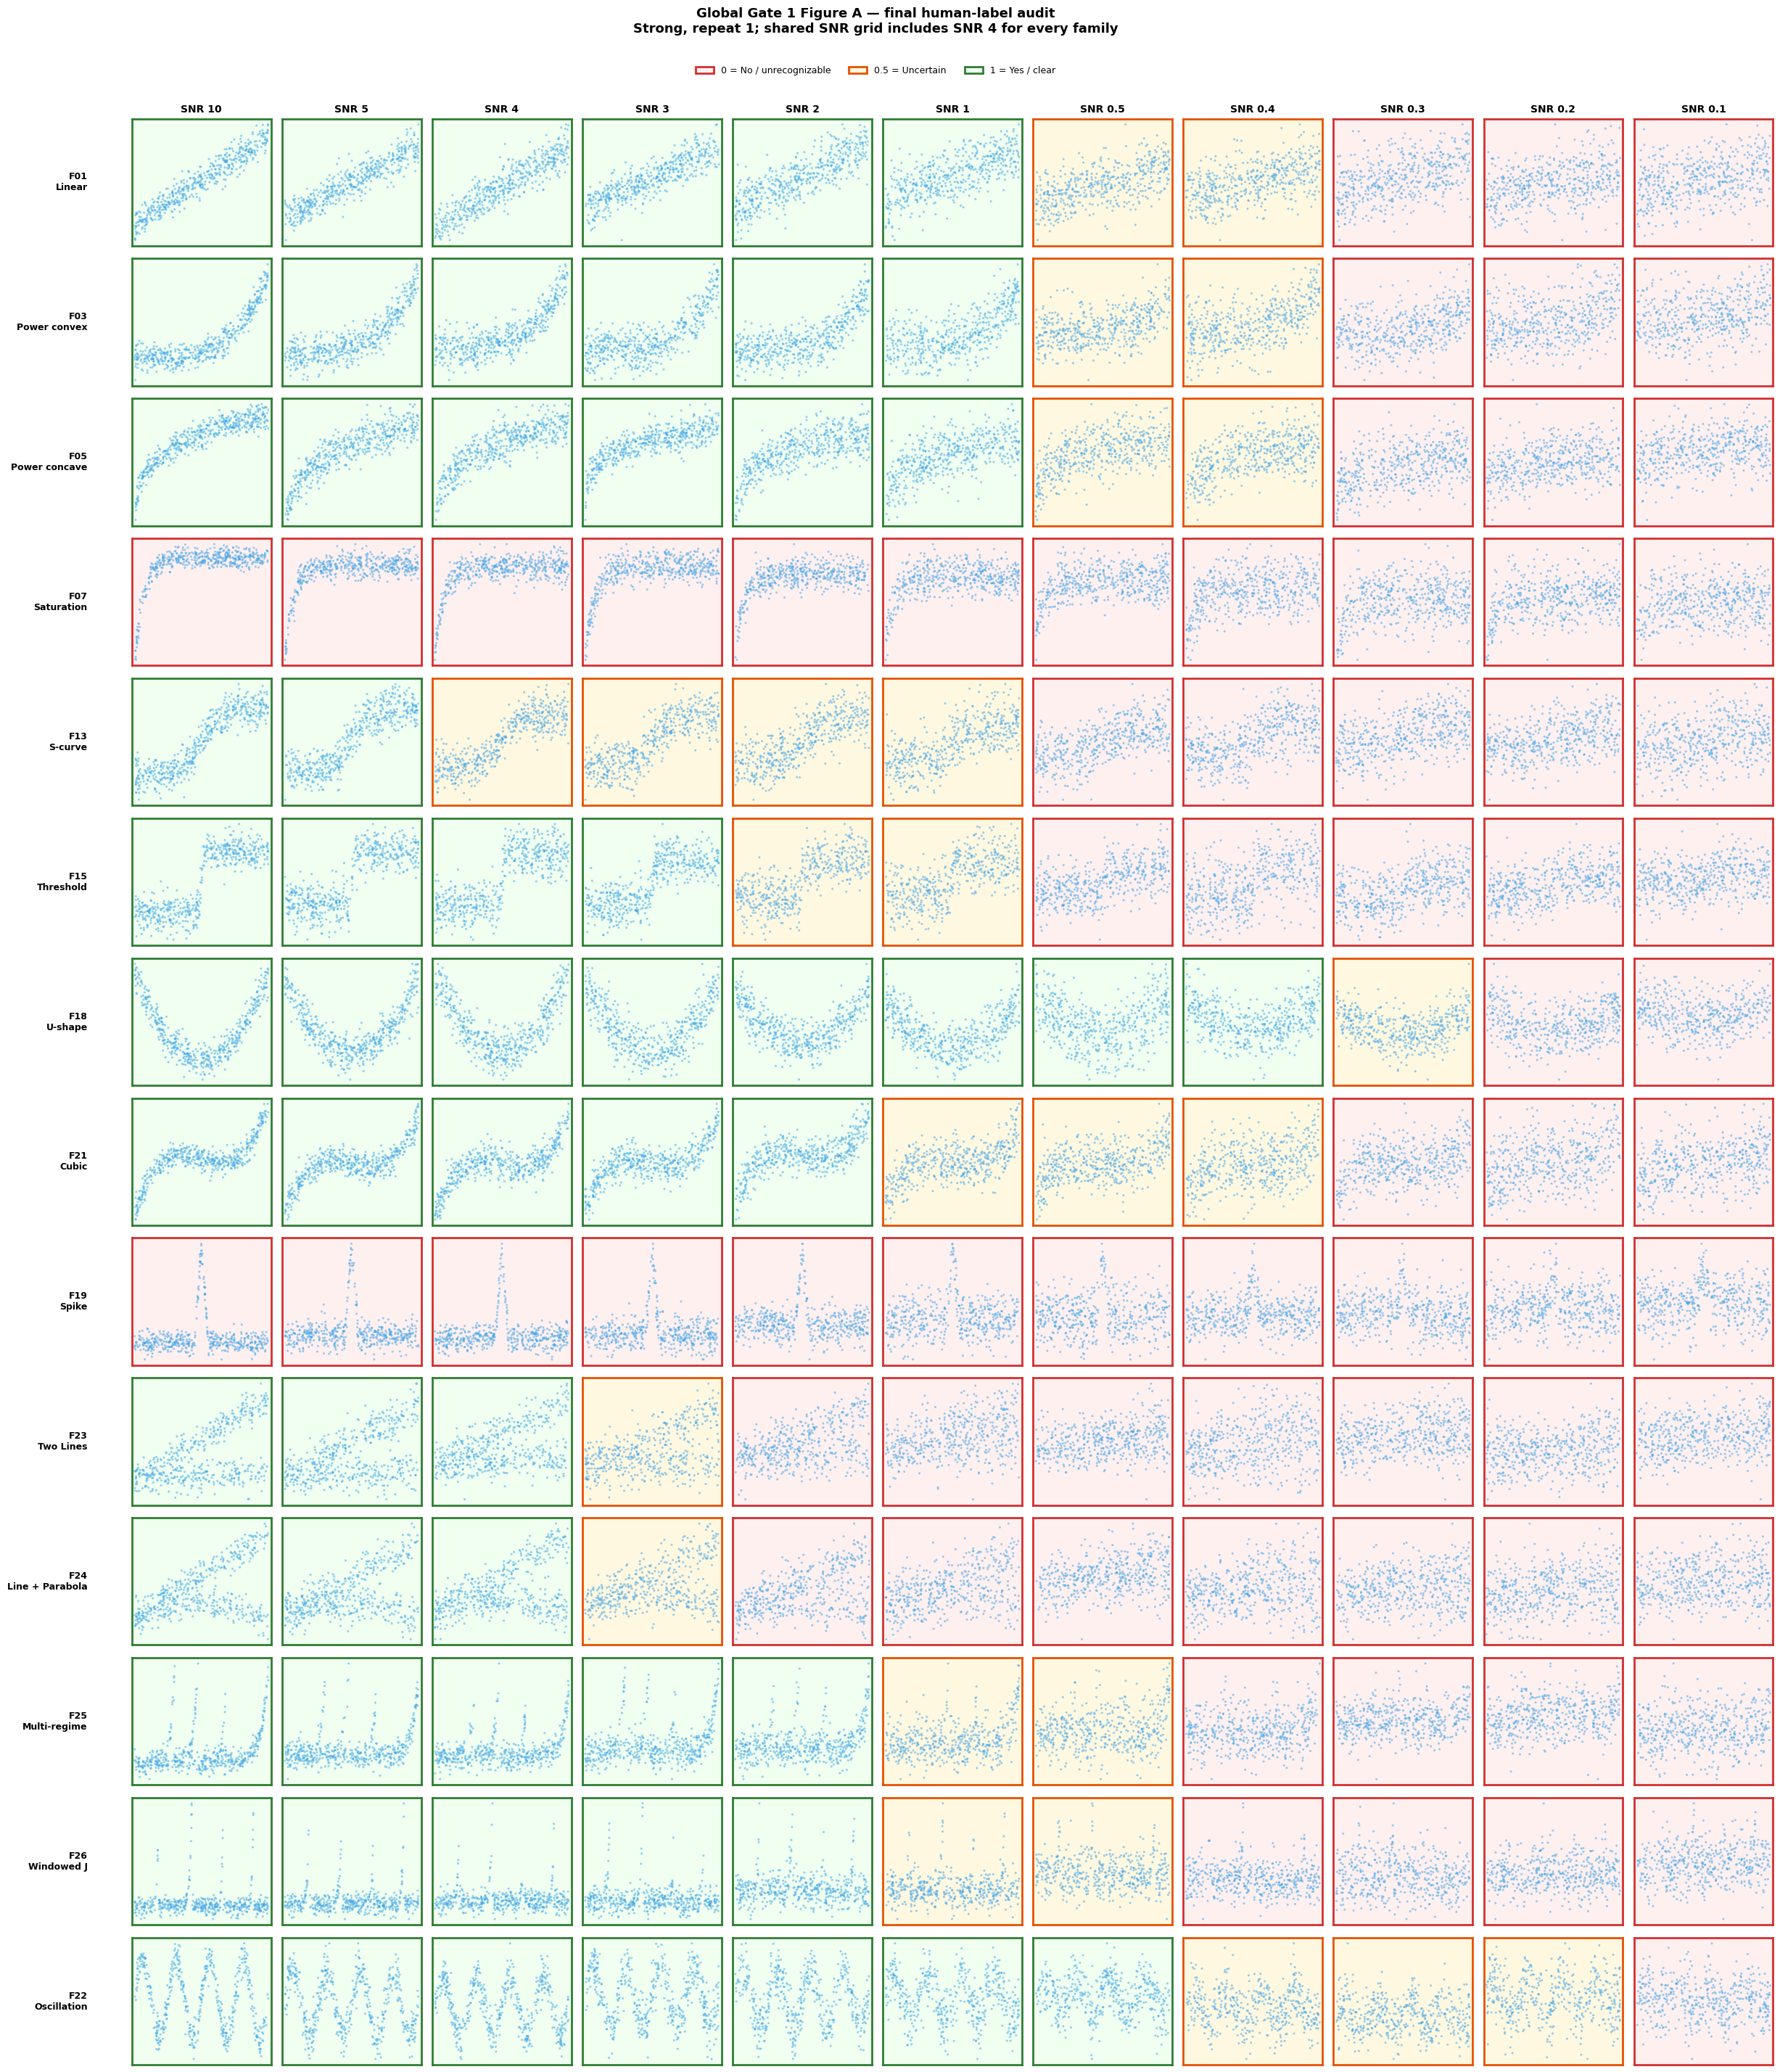

In [5]:
label_styles = {
    0.0: {'edge': '#D32F2F', 'face': '#FFF0F0', 'legend': '0 = No / unrecognizable'},
    0.5: {'edge': '#E65100', 'face': '#FFF8E1', 'legend': '0.5 = Uncertain'},
    1.0: {'edge': '#2E7D32', 'face': '#F0FFF0', 'legend': '1 = Yes / clear'},
}
figure_snr = [10.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.5, 0.4, 0.3, 0.2, 0.1]
family_order = list(dict.fromkeys(
    calibrated.loc[calibrated['family_id'].ne('Null'), 'family_id'].tolist()
))
representative = calibrated[
    calibrated['variant_level'].eq('strong')
    & calibrated['replicate'].eq(0)
    & calibrated['family_id'].ne('Null')
].copy()

fig, axes = plt.subplots(
    len(family_order), len(figure_snr),
    figsize=(25, 29), squeeze=False,
)

for row_index, family_id in enumerate(family_order):
    family_name = representative.loc[
        representative['family_id'].eq(family_id), 'family_short_name'
    ].iloc[0]
    for column_index, nominal_snr in enumerate(figure_snr):
        ax = axes[row_index, column_index]
        record = representative[
            representative['family_id'].eq(family_id)
            & np.isclose(representative['nominal_snr'], nominal_snr, rtol=0.0, atol=1e-12)
        ]
        if len(record) == 1:
            candidate_index = int(record.iloc[0]['candidate_index'])
            label = float(record.iloc[0]['label'])
            style = label_styles[label]
            ax.scatter(
                x_candidates[candidate_index], y_candidates[candidate_index],
                s=5, alpha=0.52, color='#42A5E8', edgecolors='none', rasterized=True,
            )
            ax.set_facecolor(style['face'])
            for spine in ax.spines.values():
                spine.set_color(style['edge'])
                spine.set_linewidth(2.0)
        else:
            raise ValueError(f'Expected one representative {family_id}, SNR {nominal_snr:g}; found {len(record)}')

        ax.set_xlim(-0.02, 1.02)
        ax.set_xticks([])
        ax.set_yticks([])
        if row_index == 0:
            ax.set_title(f'SNR {nominal_snr:g}', fontsize=10, fontweight='bold')
        if column_index == 0:
            ax.set_ylabel(
                f'{family_id}\n{family_name}', fontsize=9, fontweight='bold',
                rotation=0, ha='right', va='center', labelpad=44,
            )

legend_handles = [
    Patch(facecolor=label_styles[label]['face'], edgecolor=label_styles[label]['edge'],
          linewidth=2.0, label=label_styles[label]['legend'])
    for label in [0.0, 0.5, 1.0]
]
fig.suptitle(
    'Global Gate 1 Figure A — final human-label audit\n'
    'Strong, repeat 1; shared SNR grid includes SNR 4 for every family',
    fontsize=13, fontweight='bold', y=0.998,
)
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.974),
           ncol=3, frameon=False, fontsize=9)
fig.subplots_adjust(left=0.09, right=0.995, bottom=0.02, top=0.945, wspace=0.08, hspace=0.10)
figure_a_path = output_dir / 'figure_A_global_label_audit.png'
fig.savefig(figure_a_path, dpi=160, bbox_inches='tight', facecolor='white')
print(f'Saved: {figure_a_path}')
plt.show()


## 5. Figure B — MIC fuzzy calibration and variant stability

Each repeat is plotted separately. The pooled curve is the exported calibration; Standard and Strong panels show whether the fitted interval is stable across shape intensity.


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration/figure_B_mic_fuzzy_calibration.png


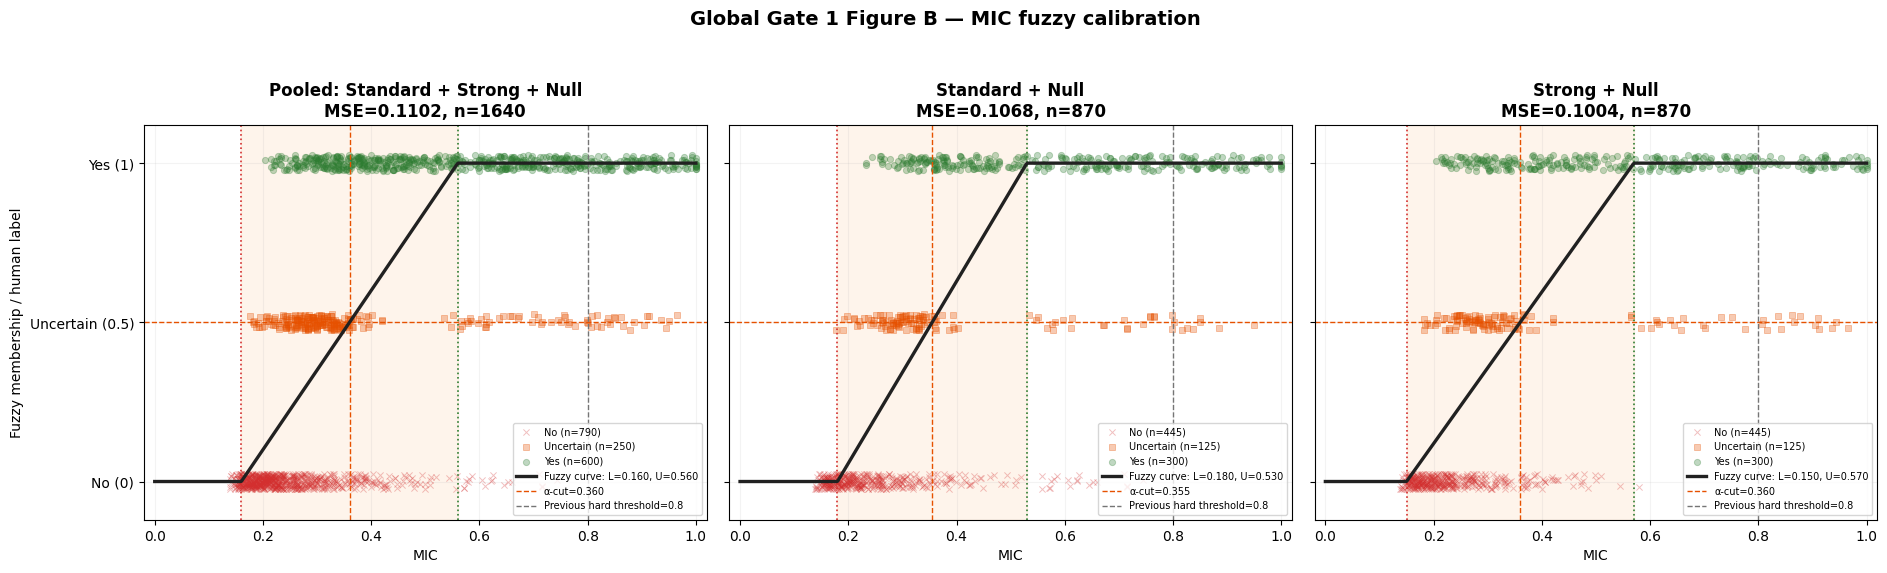

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration/figure_C_family_residual_mse.png


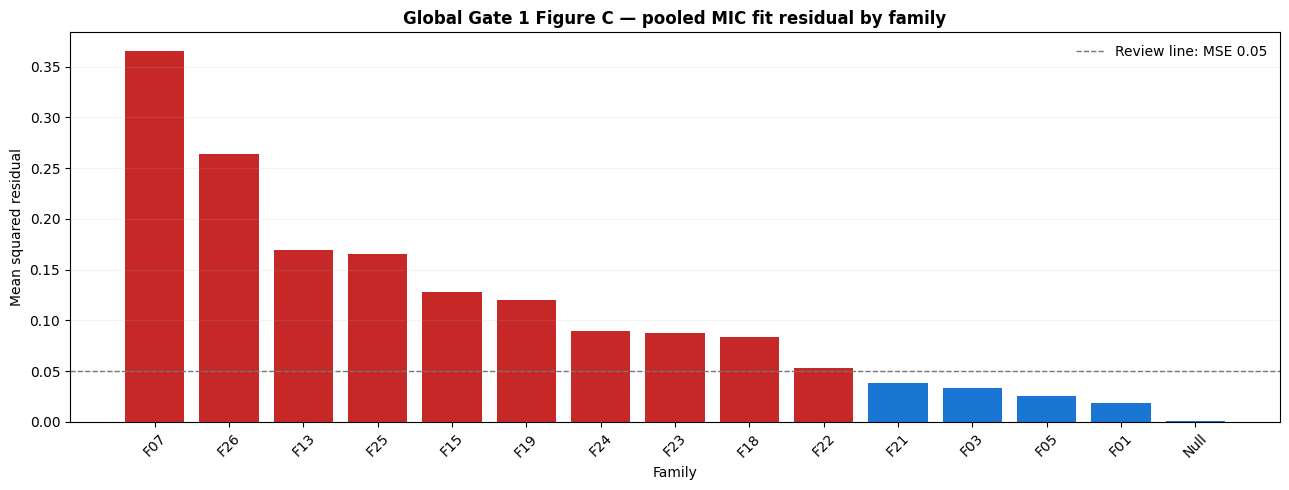

,family_id,family_short_name,cases,label_mean,MIC_mean,membership_mean,mse,mae
3,F07,Saturation,110,0.0000,0.3721,0.5005,0.3656,0.5005
13,F26,Windowed J,110,0.5455,0.2360,0.1901,0.2642,0.4173
4,F13,S-curve,110,0.3636,0.5902,0.7190,0.1694,0.3554
12,F25,Multi-regime,110,0.5455,0.2711,0.2778,0.1653,0.3370
5,F15,Threshold,110,0.4545,0.6123,0.7221,0.1279,0.2676
7,F19,Spike,110,0.0000,0.2737,0.2842,0.1201,0.2842
11,F24,Line + Parabola,110,0.3182,0.2664,0.2661,0.0892,0.2316
10,F23,Two Lines,110,0.3182,0.2804,0.3010,0.0877,0.2357
6,F18,U-shape,110,0.7727,0.4882,0.6446,0.0837,0.1816
9,F22,Oscillation,110,0.7727,0.5172,0.6443,0.0533,0.1430


In [6]:
def plot_calibrated_gate(ax, rows, fit, title):
    rng = np.random.default_rng(20260720)
    point_styles = {
        0.0: ('No', '#D32F2F', 'x'),
        0.5: ('Uncertain', '#E65100', 's'),
        1.0: ('Yes', '#2E7D32', 'o'),
    }
    for label, (name, color, marker) in point_styles.items():
        selected = rows[np.isclose(rows['label'], label)]
        jitter = rng.uniform(-0.025, 0.025, len(selected))
        ax.scatter(
            selected['MIC'], selected['label'] + jitter,
            color=color, marker=marker, s=20, alpha=0.30,
            linewidths=0.7, label=f'{name} (n={len(selected)})', zorder=2,
        )

    grid = np.linspace(0.0, 1.0, 500)
    curve = fuzzy_mu(grid, fit['L'], fit['U'])
    alpha_x = fit['L'] + ALPHA * (fit['U'] - fit['L'])
    ax.axvspan(fit['L'], fit['U'], color='#F57C00', alpha=0.08, zorder=0)
    ax.plot(grid, curve, color='#212121', linewidth=2.4,
            label=f'Fuzzy curve: L={fit["L"]:.3f}, U={fit["U"]:.3f}', zorder=4)
    ax.axvline(fit['L'], color='#D32F2F', linestyle=':', linewidth=1.2)
    ax.axvline(fit['U'], color='#2E7D32', linestyle=':', linewidth=1.2)
    ax.axhline(ALPHA, color='#E65100', linestyle='--', linewidth=1.0)
    ax.axvline(alpha_x, color='#E65100', linestyle='--', linewidth=1.0,
               label=f'α-cut={alpha_x:.3f}')
    ax.axvline(HARD_MIC_THRESHOLD, color='#757575', linestyle='--', linewidth=1.0,
               label=f'Previous hard threshold={HARD_MIC_THRESHOLD:g}')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.12, 1.12)
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.set_yticklabels(['No (0)', 'Uncertain (0.5)', 'Yes (1)'])
    ax.set_xlabel('MIC')
    ax.set_title(f'{title}\nMSE={fit["mse"]:.4f}, n={fit["n"]}', fontweight='bold')
    ax.grid(True, alpha=0.15)
    ax.legend(fontsize=7, loc='lower right')

fig, axes = plt.subplots(1, 3, figsize=(19, 5.8), sharex=True, sharey=True)
plot_calibrated_gate(axes[0], calibrated, pooled_fit, 'Pooled: Standard + Strong + Null')
for axis, variant_level in zip(axes[1:], ['standard', 'strong']):
    rows = calibrated[
        calibrated['variant_level'].eq(variant_level)
        | calibrated['family_id'].eq('Null')
    ]
    plot_calibrated_gate(axis, rows, variant_fits[variant_level], variant_level.title() + ' + Null')
axes[0].set_ylabel('Fuzzy membership / human label')
fig.suptitle('Global Gate 1 Figure B — MIC fuzzy calibration', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
figure_b_path = output_dir / 'figure_B_mic_fuzzy_calibration.png'
fig.savefig(figure_b_path, dpi=170, bbox_inches='tight', facecolor='white')
print(f'Saved: {figure_b_path}')
plt.show()

family_fit_summary = (
    calibrated.groupby(['family_id', 'family_short_name'], dropna=False)
    .agg(
        cases=('candidate_index', 'size'),
        label_mean=('label', 'mean'),
        MIC_mean=('MIC', 'mean'),
        membership_mean=('mic_membership', 'mean'),
        mse=('mic_residual', lambda values: float(np.mean(values ** 2))),
        mae=('mic_absolute_error', 'mean'),
    )
    .reset_index()
    .sort_values('mse', ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = np.where(family_fit_summary['mse'].gt(0.05), '#C62828', '#1976D2')
ax.bar(family_fit_summary['family_id'], family_fit_summary['mse'], color=bar_colors)
ax.axhline(0.05, color='#757575', linestyle='--', linewidth=1.0, label='Review line: MSE 0.05')
ax.set_xlabel('Family')
ax.set_ylabel('Mean squared residual')
ax.set_title('Global Gate 1 Figure C — pooled MIC fit residual by family', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.15)
ax.legend(frameon=False)
fig.tight_layout()
figure_c_path = output_dir / 'figure_C_family_residual_mse.png'
fig.savefig(figure_c_path, dpi=170, bbox_inches='tight', facecolor='white')
print(f'Saved: {figure_c_path}')
plt.show()

display(family_fit_summary.round(4))


## 6. Export the calibrated Gate 1 artifacts

The calibrated manifest preserves every tracking field and adds the final human label, MIC, fuzzy membership, residual, and alpha-cut decision. Parameters and audit summaries are saved separately for downstream training and review.


In [7]:
label_audit = (
    calibrated.groupby(
        ['family_id', 'family_short_name', 'variant_level', 'nominal_snr', 'actual_snr'],
        dropna=False,
    )
    .agg(
        cases=('candidate_index', 'size'),
        label=('label', 'first'),
        unique_labels=('label', 'nunique'),
        MIC_mean=('MIC', 'mean'),
        MIC_sd=('MIC', 'std'),
        membership_mean=('mic_membership', 'mean'),
        membership_sd=('mic_membership', 'std'),
        mae=('mic_absolute_error', 'mean'),
    )
    .reset_index()
)
assert label_audit['unique_labels'].eq(1).all()

params = {
    'indicator': 'MIC',
    'membership': 'clip((MIC - L) / (U - L), 0, 1)',
    'alpha': ALPHA,
    'alpha_cut_mic': float(alpha_cut),
    'previous_hard_threshold': HARD_MIC_THRESHOLD,
    'pooled': {key: (bool(value) if isinstance(value, np.bool_) else value)
               for key, value in pooled_fit.items()},
    'by_variant': variant_fits,
    'label_counts': {
        str(label): int(count)
        for label, count in calibrated['label'].value_counts().sort_index().items()
    },
    'snr4_label_overrides': {
        f'{family_id}_snr_{snr:g}': label
        for (family_id, snr), label in SNR4_LABEL_OVERRIDES.items()
    },
    'n_candidates': int(len(calibrated)),
    'n_signal': int(calibrated['family_id'].ne('Null').sum()),
    'n_null': int(calibrated['family_id'].eq('Null').sum()),
}

calibrated_manifest_path = output_dir / 'gate1_calibrated_manifest.csv'
params_path = output_dir / 'gate1_fuzzy_params.json'
label_audit_path = output_dir / 'gate1_label_audit.csv'
family_summary_path = output_dir / 'gate1_family_fit_summary.csv'

calibrated.to_csv(calibrated_manifest_path, index=False)
with open(params_path, 'w') as output_file:
    json.dump(params, output_file, indent=2)
label_audit.to_csv(label_audit_path, index=False)
family_fit_summary.to_csv(family_summary_path, index=False)

print('Calibration complete')
print(f'  Pooled L/U: {MIC_L:.3f} / {MIC_U:.3f}')
print(f'  Alpha-cut MIC: {alpha_cut:.3f}')
print(f'  Pooled MSE: {pooled_fit_auto["mse"]:.4f}')
print(f'  Calibrated candidates: {len(calibrated):,}')
print(f'  Manifest: {calibrated_manifest_path}')
print(f'  Parameters: {params_path}')
print(f'  Label audit: {label_audit_path}')
print(f'  Family fit summary: {family_summary_path}')


Calibration complete
  Pooled L/U: 0.160 / 0.560
  Alpha-cut MIC: 0.360
  Pooled MSE: 0.1102
  Calibrated candidates: 1,640
  Manifest: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration/gate1_calibrated_manifest.csv
  Parameters: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration/gate1_fuzzy_params.json
  Label audit: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration/gate1_label_audit.csv
  Family fit summary: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S2_gate1_fuzzy_calibration/gate1_family_fit_summary.csv
